# **Feature Selection for baseline data**

### *Clinical Trial CTN-0051: Extended-Release Naltroxone vs. Buprenorphine for Opioid Treatment*

This notebook includes feature selection as well as one-hot encoding. This is the last part of the preprocessing pipeline. 

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
import numpy as np

In [ ]:
# ── Load files ────────────────────────────────────────────────────────────────
baseline = pd.read_csv("../clean-data/pre-trial.csv")
target   = pd.read_csv("../clean-data/retention_tier.csv")

# ── Join on PATID — keep full target for downstream cells ─────────────────────
df = baseline.merge(target, on='PATID', how='inner')
y  = df['retention_tier']
X  = df.drop(columns=['retention_tier', 'completed'])
print(f"EDA dataframe shape: {X.shape}")

## One-hot encoding

In [ ]:
# ── Human-readable renaming of one-hot encoded columns ───────────────────────

ohe_rename = {
    # Last opioid substance (reference = Methadone)
    'last_substance_code_2.0'  : 'subst_oxycodone',
    'last_substance_code_3.0'  : 'subst_hydrocodone',
    'last_substance_code_4.0'  : 'subst_heroin',
    'last_substance_code_5.0'  : 'subst_buprenorphine',
    'last_substance_code_6.0'  : 'subst_hydromorphone',
    'last_substance_code_7.0'  : 'subst_oxymorphone',
    'last_substance_code_9.0'  : 'subst_codeine',
    'last_substance_code_11.0' : 'subst_morphine',

    # Route of administration (reference = Oral)
    'last_route_code_2.0'      : 'route_nasal',
    'last_route_code_3.0'      : 'route_smoking',
    'last_route_code_4.0'      : 'route_non_iv_injection',
    'last_route_code_5.0'      : 'route_iv_injection',

    # Occupation category (reference = category 1)
    'occupation_category_2.0'  : 'occup_part_time',
    'occupation_category_3.0'  : 'occup_unemployed_looking',
    'occupation_category_4.0'  : 'occup_unemployed_not_looking',
    'occupation_category_5.0'  : 'occup_student',
    'occupation_category_6.0'  : 'occup_retired_disabled',
    'occupation_category_7.0'  : 'occup_homemaker',
    'occupation_category_8.0'  : 'occup_prison_controlled',
    'occupation_category_9.0'  : 'occup_other',

    # Discharge facility (reference = Outpatient)
    'discharge_facility_code_1.0' : 'discharge_residential',
}

# Apply rename — only rename columns that actually exist
X = X.rename(columns={k: v for k, v in ohe_rename.items() if k in X.columns})

# Verify no raw-coded columns remain
remaining_raw = [c for c in X.columns if any(
    c.startswith(p) for p in ['last_substance_code_', 'last_route_code_',
                               'occupation_category_', 'discharge_facility_code_']
)]
if remaining_raw:
    print(f"Warning: raw-coded columns still present: {remaining_raw}")
else:
    print("All OHE columns successfully renamed.")

print(f"\nFinal feature matrix: {X.shape}")
print(f"\nColumn list:")
for c in X.columns:
    print(f"  {c}")

In [29]:
# ── Spearman correlations between all features and retention_tier ─────────────
from scipy import stats

corr_records = []
for col in X.columns:
    rho, p = stats.spearmanr(X[col], y, nan_policy='omit')
    corr_records.append({
        'feature'   : col,
        'spearman_r': round(rho, 4),
        'p_value'   : round(p,   4),
        'significant': p < 0.05,
    })

corr_df = (
    pd.DataFrame(corr_records)
    .sort_values('spearman_r', ascending=False)
    .reset_index(drop=True)
)

print("── Spearman correlations with retention_tier ────────────────────────────")
print(corr_df.to_string(index=False))
print(f"\nSignificant features (p < 0.05): "
      f"{corr_df['significant'].sum()} / {len(corr_df)}")

── Spearman correlations with retention_tier ────────────────────────────
                           feature  spearman_r  p_value  significant
          discharge_facility_label      0.1044   0.0140         True
           discharge_facility_code      0.1044   0.0140         True
                         detox_los      0.0841   0.0480         True
              sow_anxiety_baseline      0.0593   0.1635        False
               has_drivers_licence      0.0508   0.2322        False
           days_any_employment_30d      0.0498   0.2418        False
                dsm_cannabis_score      0.0457   0.2834        False
              sow_shaking_baseline      0.0455   0.2846        False
         sow_restlessness_baseline      0.0415   0.3292        False
                   education_years      0.0389   0.3610        False
                  dsm_opioid_score      0.0371   0.3836        False
             income_employment_30d      0.0353   0.4072        False
              last_substance_

C:\Users\Miki\AppData\Local\Temp\ipykernel_29372\995799538.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(X[col], y, nan_policy='omit')


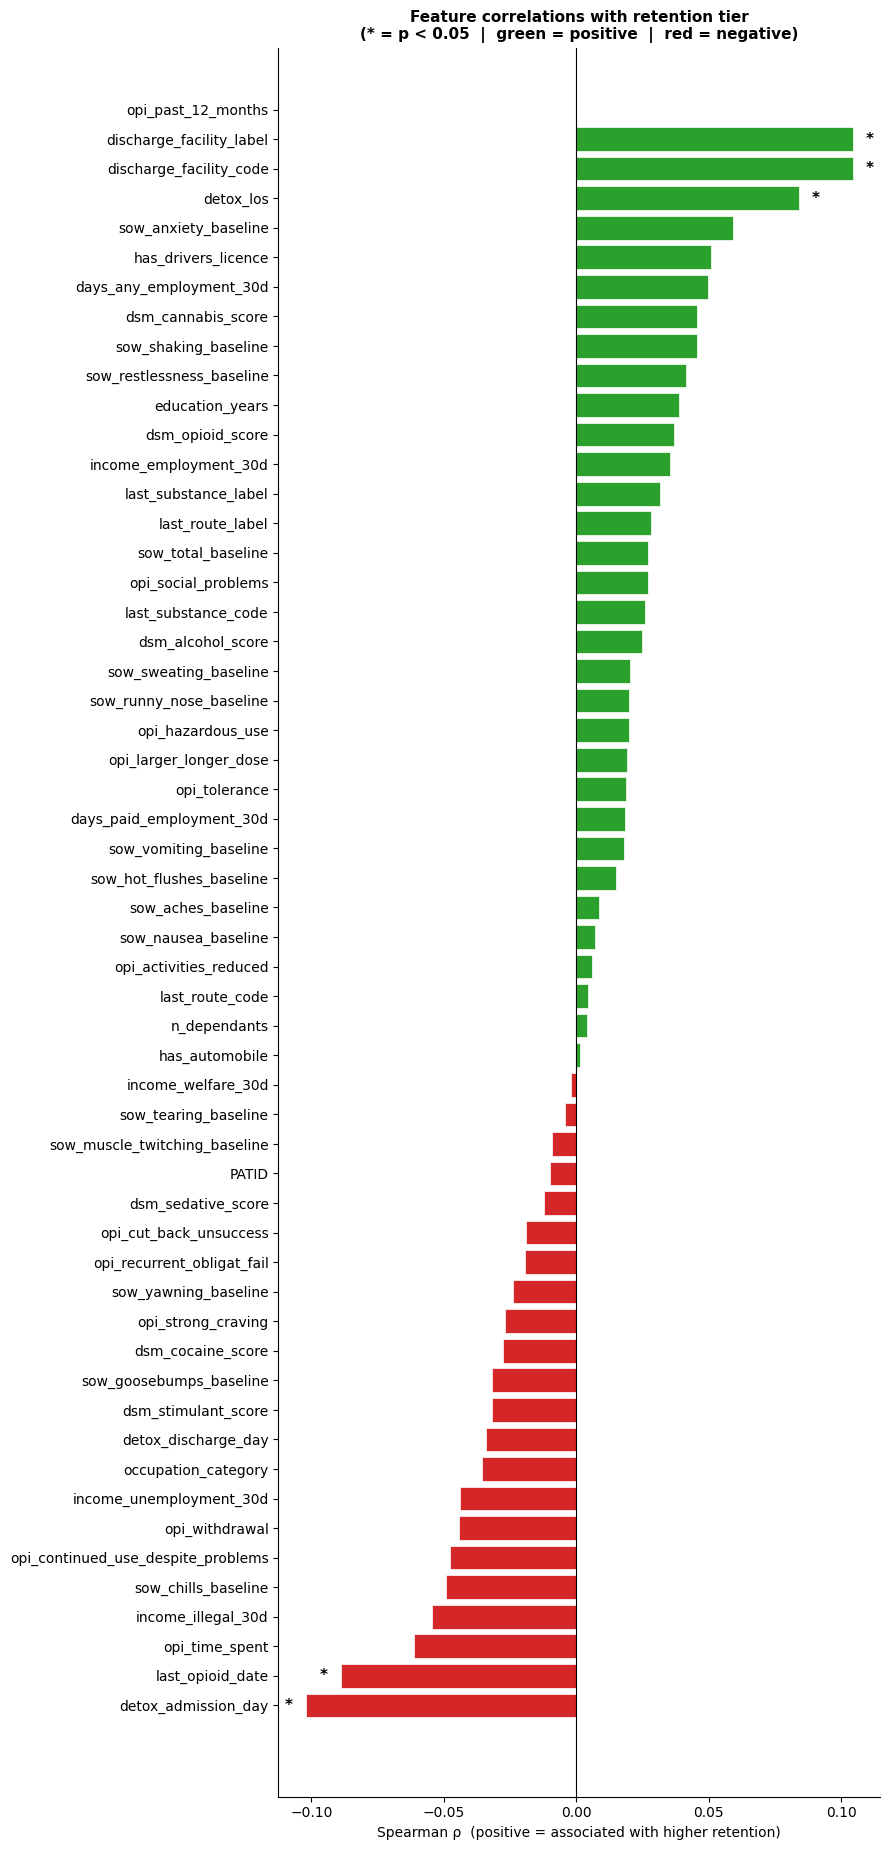

In [30]:
# ── Visualisation: sorted correlation bar chart ───────────────────────────────
corr_sorted = corr_df.sort_values('spearman_r')

fig, ax = plt.subplots(figsize=(9, len(corr_sorted) * 0.32 + 1))

bar_colors = [
    '#d62728' if row['spearman_r'] < 0 else '#2ca02c'
    for _, row in corr_sorted.iterrows()
]
bars = ax.barh(
    corr_sorted['feature'],
    corr_sorted['spearman_r'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
)

# Mark significant features with *
for i, (_, row) in enumerate(corr_sorted.iterrows()):
    if row['significant']:
        x_offset = 0.005 if row['spearman_r'] >= 0 else -0.005
        ha = 'left' if row['spearman_r'] >= 0 else 'right'
        ax.text(row['spearman_r'] + x_offset, i, '*',
                va='center', ha=ha, fontsize=11, color='black', fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman ρ  (positive = associated with higher retention)',
              fontsize=10)
ax.set_title(
    'Feature correlations with retention tier\n'
    '(* = p < 0.05  |  green = positive  |  red = negative)',
    fontsize=11, fontweight='bold'
)
sns.despine()
plt.tight_layout()
plt.savefig('ohe_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── One-hot encode nominal columns, drop string labels + zero-variance ─────────
drop_cols    = ['last_substance_label', 'last_route_label', 'discharge_facility_label',
                'opi_past_12_months', 'PATID',
                'completed']          # binary target — derived from retention_tier
nominal_cols = ['last_substance_code', 'last_route_code',
                'occupation_category', 'discharge_facility_code']

df_enc = df.drop(columns=[c for c in drop_cols if c in df.columns])
df_enc = pd.get_dummies(df_enc, columns=nominal_cols, drop_first=True, dtype=int)

# ── Feature matrix and target ─────────────────────────────────────────────────
X = df_enc.drop(columns='retention_tier')
y = df_enc['retention_tier']

print(f"Feature matrix : {X.shape}")
print(f"Target distribution:\n{y.value_counts().sort_index().to_string()}")

Feature matrix : (554, 67)
Target distribution:
retention_tier
1    164
2    108
3     61
4    221


In [34]:
X.head(5)

,last_opioid_date,detox_admission_day,detox_discharge_day,detox_los,dsm_opioid_score,dsm_alcohol_score,dsm_stimulant_score,dsm_cannabis_score,dsm_cocaine_score,dsm_sedative_score,...,last_route_code_5.0,occupation_category_2.0,occupation_category_3.0,occupation_category_4.0,occupation_category_5.0,occupation_category_6.0,occupation_category_7.0,occupation_category_8.0,occupation_category_9.0,discharge_facility_code_1.0
0,0.0,-10.0,4.0,14.0,1,2,4,3,2,1,...,0,0,0,0,0,0,1,0,0,0
1,0.0,-3.0,15.0,18.0,1,2,4,3,1,3,...,0,0,0,0,1,0,0,0,0,0
2,0.0,-6.0,2.0,8.0,1,4,4,4,4,4,...,0,0,0,0,0,0,1,0,0,0
3,0.0,-4.0,4.0,8.0,1,4,4,4,4,4,...,0,0,0,0,0,1,0,0,0,0
4,0.0,-1.0,8.0,9.0,1,4,4,4,4,4,...,0,0,0,0,1,0,0,0,0,0


## L1 Logistic Regression — binary feature selection (completed vs. not completed)

In [35]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline

y_binary = (df_enc['retention_tier'] == 4).astype(int)
print(f"Class balance — not completed: {(y_binary==0).sum()}  |  completed: {(y_binary==1).sum()}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline: scaler is fit only on training folds — no leakage
pipe_l1 = Pipeline([
    ('clf', LogisticRegressionCV(
        Cs=np.logspace(-4, 2, 100),
        penalty='l1',
        solver='saga',
        cv=cv,
        scoring='accuracy',
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1,
    ))
])

# Unbiased performance via outer CV
cv_results = cross_validate(
    pipe_l1, X, y_binary,
    cv=cv,
    scoring=['accuracy', 'f1_weighted'],
    return_train_score=False,
)

print(f"\nCV Accuracy     : {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}")
print(f"CV F1-weighted: {cv_results['test_f1_weighted'].mean():.3f} ± {cv_results['test_f1_weighted'].std():.3f}")

# Fit on full data to extract coefficients for interpretation
pipe_l1.fit(X, y_binary)
clf       = pipe_l1.named_steps['clf']
best_C    = clf.C_[0]
n_selected = (clf.coef_[0] != 0).sum()

print(f"\nBest C (full fit): {best_C:.5f}  (λ = {1/best_C:.4f})")
print(f"Features selected: {n_selected} / {X.shape[1]}")
print(f"\nClassification report (full-data fit — for inspection only):")
print(classification_report(y_binary, pipe_l1.predict(X), target_names=['not completed', 'completed']))

Class balance — not completed: 333  |  completed: 221

CV Accuracy     : 0.504 ± 0.042
CV F1-weighted: 0.494 ± 0.044

Best C (full fit): 0.00046  (λ = 2154.4347)
Features selected: 3 / 67

Classification report (full-data fit — for inspection only):
               precision    recall  f1-score   support

not completed       0.63      0.36      0.46       333
    completed       0.42      0.69      0.52       221

     accuracy                           0.49       554
    macro avg       0.52      0.52      0.49       554
 weighted avg       0.55      0.49      0.48       554



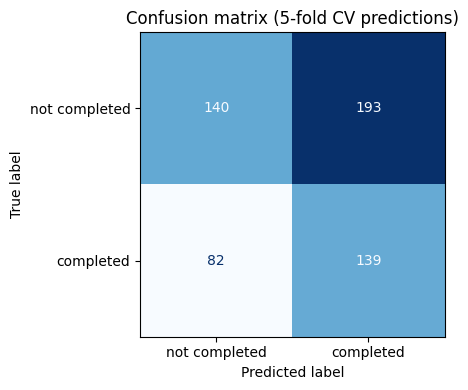

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(pipe_l1, X, y_binary, cv=cv)

cm = confusion_matrix(y_binary, y_pred_cv)
disp = ConfusionMatrixDisplay(cm, display_labels=['not completed', 'completed'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion matrix (5-fold CV predictions)')
plt.tight_layout()
plt.show()

Selected features (3):
income_unemployment_30d   -0.0001
income_illegal_30d        -0.0001
income_employment_30d      0.0000


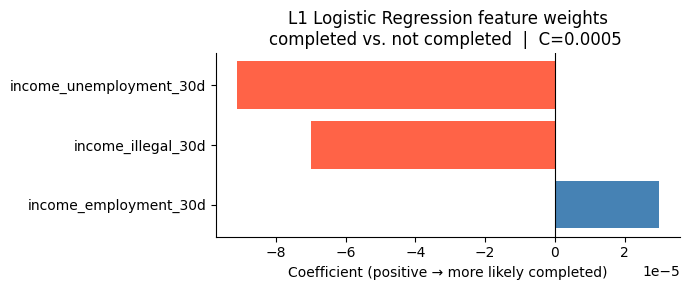

In [36]:
coef_lr     = pd.Series(clf.coef_[0], index=X.columns)
selected_lr = coef_lr[coef_lr != 0].sort_values(key=abs, ascending=False)

print(f"Selected features ({len(selected_lr)}):")
print(selected_lr.round(4).to_string())

fig, ax = plt.subplots(figsize=(7, max(len(selected_lr) * 0.4 + 1, 3)))
colors = ['steelblue' if v > 0 else 'tomato' for v in selected_lr.values[::-1]]
ax.barh(selected_lr.index[::-1], selected_lr.values[::-1], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (positive → more likely completed)')
ax.set_title(
    f'L1 Logistic Regression feature weights\n'
    f'completed vs. not completed  |  C={best_C:.4f} '
)
sns.despine()
plt.tight_layout()
plt.show()

## Random Forest — binary classification (completed vs. not completed)

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

cv_rf = cross_validate(
    rf, X, y_binary,
    cv=cv,
    scoring=['accuracy', 'roc_auc', 'f1_weighted'],
    return_train_score=False,
)

print("── Random Forest (5-fold CV) ────────────────────────────────────────────")
print(f"Accuracy          : {cv_rf['test_accuracy'].mean():.3f} ± {cv_rf['test_accuracy'].std():.3f}")
print(f"ROC-AUC           : {cv_rf['test_roc_auc'].mean():.3f} ± {cv_rf['test_roc_auc'].std():.3f}")
print(f"F1-weighted       : {cv_rf['test_f1_weighted'].mean():.3f} ± {cv_rf['test_f1_weighted'].std():.3f}")

# # Recompute LR balanced accuracy for direct comparison
# ba_lr = accuracy_score(y_binary, y_pred_cv)
# print(f"\n── Comparison ( accuracy) ───────────────────────────────────────")
# print(f"L1 Logistic Regression : {ba_lr:.3f}  (from CV predictions)")
# print(f"Random Forest          : {cv_rf['test_accuracy'].mean():.3f}  (CV mean)")

# Fit on full data to get feature importances
rf.fit(X, y_binary)

── Random Forest (5-fold CV) ────────────────────────────────────────────
Accuracy          : 0.578 ± 0.021
ROC-AUC           : 0.528 ± 0.031
F1-weighted       : 0.494 ± 0.022


,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


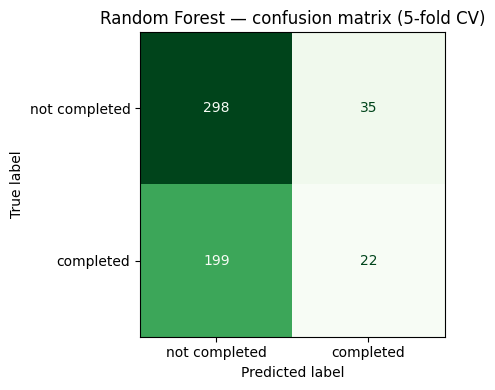

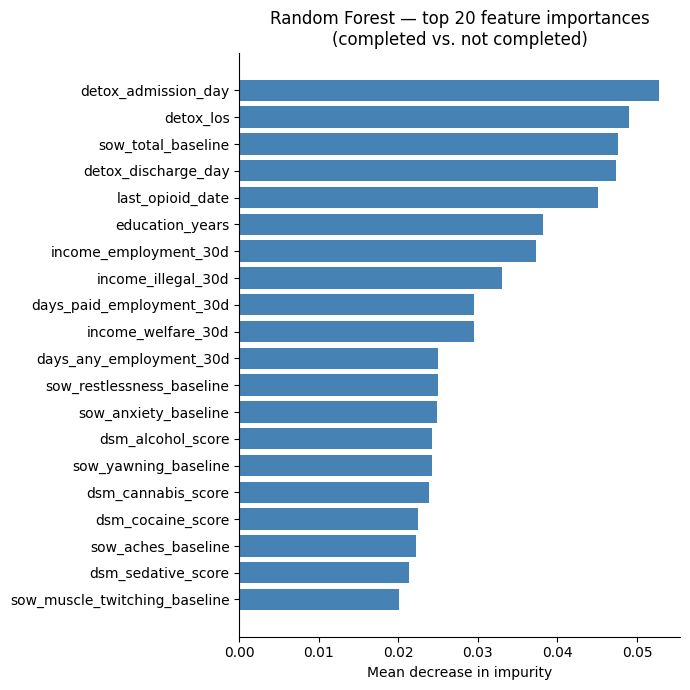

In [45]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Confusion matrix ──────────────────────────────────────────────────────────
y_pred_rf = cross_val_predict(rf, X, y_binary, cv=cv)

cm_rf = confusion_matrix(y_binary, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['not completed', 'completed'])

fig, ax = plt.subplots(figsize=(5, 4))
disp_rf.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Random Forest — confusion matrix (5-fold CV)')
plt.tight_layout()
plt.show()

# ── Feature importances ───────────────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(importances.index[::-1], importances.values[::-1], color='steelblue')
ax.set_xlabel('Mean decrease in impurity')
ax.set_title('Random Forest — top 20 feature importances\n(completed vs. not completed)')
sns.despine()
plt.tight_layout()
plt.show()

In [46]:
print(classification_report(y_binary, y_pred_rf, target_names=['not completed', 'completed']))

               precision    recall  f1-score   support

not completed       0.60      0.89      0.72       333
    completed       0.39      0.10      0.16       221

     accuracy                           0.58       554
    macro avg       0.49      0.50      0.44       554
 weighted avg       0.51      0.58      0.49       554

